<a href="https://colab.research.google.com/github/massi77777/first-project/blob/main/dayabit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: Logistic Regression
Accuracy: 0.715
Recall: 0.6831683168316832
Precision: 0.7340425531914894
F1 Score: 0.7076923076923077


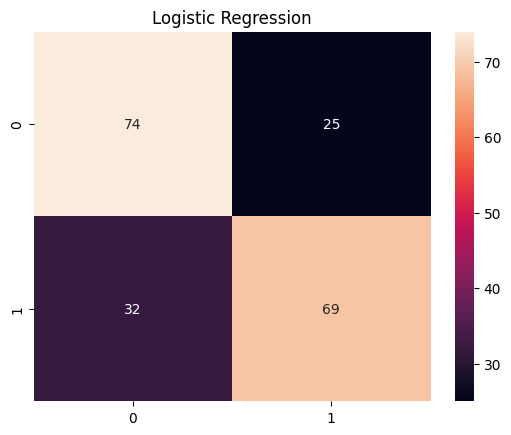

Model: SVC
Accuracy: 0.705
Recall: 0.6435643564356436
Precision: 0.7386363636363636
F1 Score: 0.6878306878306878


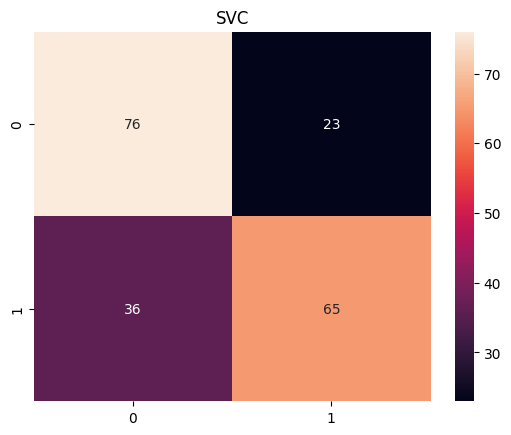

Model: Random Forest
Accuracy: 0.85
Recall: 0.900990099009901
Precision: 0.8198198198198198
F1 Score: 0.8584905660377359


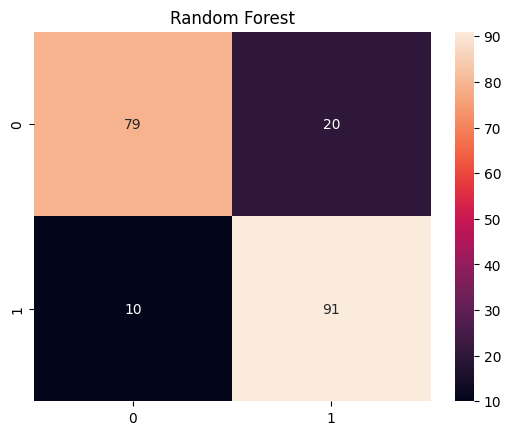

Model: Gradient Boosting
Accuracy: 0.77
Recall: 0.7821782178217822
Precision: 0.7669902912621359
F1 Score: 0.7745098039215687


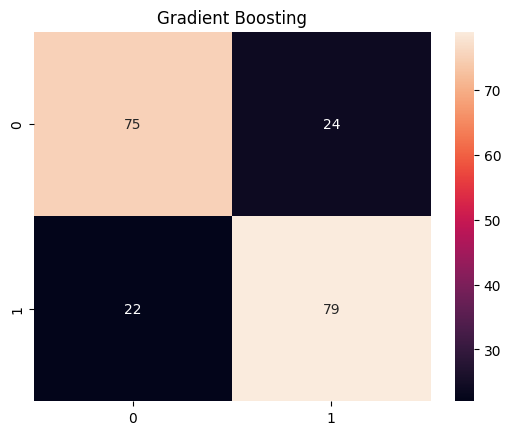

                 Model  Accuracy    Recall  Precision  F1 Score
0  Logistic Regression     0.715  0.683168   0.734043  0.707692
1                  SVC     0.705  0.643564   0.738636  0.687831
2        Random Forest     0.850  0.900990   0.819820  0.858491
3    Gradient Boosting     0.770  0.782178   0.766990  0.774510


In [ ]:
# =========================
# 1. Import Libraries
# =========================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import RandomOverSampler


# =========================
# 2. Load Dataset
# =========================

data = pd.read_csv("diabetes (1).csv")

# Features and Target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]


# =========================
# 3. Balance Dataset
# =========================

ros = RandomOverSampler(random_state=41)
X_res, y_res = ros.fit_resample(X, y)


# =========================
# 4. Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


# =========================
# 5. Models
# =========================

models = {
    "Logistic Regression": LogisticRegression(),
    "SVC": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}


# =========================
# 6. Train and Evaluate
# =========================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, rec, prec, f1])

    print("Model:", name)
    print("Accuracy:", acc)
    print("Recall:", rec)
    print("Precision:", prec)
    print("F1 Score:", f1)

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
    plt.title(name)
    plt.show()


# =========================
# 7. Results Table
# =========================

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Recall", "Precision", "F1 Score"]
)

print(results_df)

In [ ]:
results_df

,Model,Accuracy,Recall,Precision,F1 Score
0,Logistic Regression,0.715,0.683168,0.734043,0.707692
1,SVC,0.705,0.643564,0.738636,0.687831
2,Random Forest,0.825,0.881188,0.794643,0.835681
3,Gradient Boosting,0.780,0.792079,0.776699,0.784314
